In [ ]:
import sys
sys.path.append('..')

from src.binomial_tree import crr_call, crr_put, crr_american_call, crr_american_put
from src.black_scholes import call_price, put_price
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

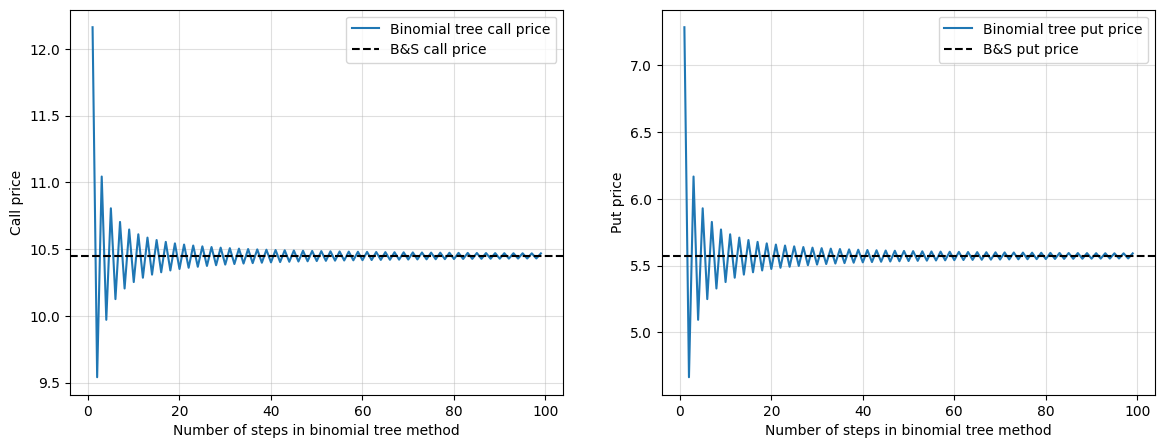

In [ ]:
max_n_steps = 100
x = list(range(1, max_n_steps))
crr_call_prices = [crr_call(S, K, T, r, sigma, n_steps) for n_steps in x]
crr_put_prices = [crr_put(S, K, T, r, sigma, n_steps) for n_steps in x]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax[0].plot(x, crr_call_prices, label='Binomial tree call price')
ax[0].axhline(call_price(S, K, T, r, sigma), color='black', linestyle='--', label='B&S call price')
ax[0].set_xlabel('Number of steps in binomial tree method')
ax[0].set_ylabel('Call price')
ax[0].legend()
ax[0].grid(True, alpha=0.4)

ax[1].plot(x, crr_put_prices, label='Binomial tree put price')
ax[1].axhline(put_price(S, K, T, r, sigma), color='black', linestyle='--', label='B&S put price')
ax[1].set_xlabel('Number of steps in binomial tree method')
ax[1].set_ylabel('Put price')
ax[1].legend()
ax[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

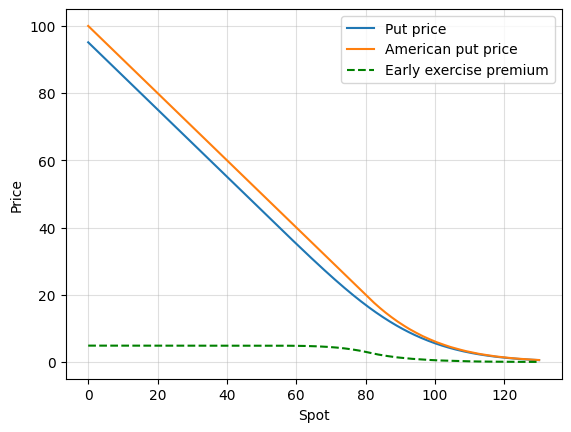

In [ ]:
x = np.linspace(0.01, 130, 520)
put_prices = [put_price(s , K, T, r, sigma) for s in x]
american_put_prices = [crr_american_put(s, K, T, r, sigma) for s in x]
early_exercise_premium = [a - e for a, e in zip(american_put_prices, put_prices)]

plt.plot(x, put_prices, label='Put price')
plt.plot(x, american_put_prices, label='American put price')
plt.plot(x, early_exercise_premium, label='Early exercise premium', linestyle='--', color='green')
plt.xlabel('Spot')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()